## Instlacja i import bibliotek

In [ ]:
#pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pyarrow
import pandas as pd
import sqlite3
import numpy
import geopandas
import geopy
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import xgboost
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import tabulate

## Import wszystkich danych

In [2]:
DB_FILE_PATH = "Dane/ceny_mieszkan.db"

In [3]:
conn = sqlite3.connect(DB_FILE_PATH)
df = pd.read_sql_query("SELECT * FROM mieszkanka", conn)
conn.close()

## Czyścimy dane
Czyścimy niepotrzebne nam dane

In [4]:
df.describe()

,id,area,price,lat,lng,floor,floors,balcony,loggia,terrace,garden
count,99170.000000,99170.000000,9.917000e+04,99170.000000,99170.000000,95730.000000,99170.000000,35211.000000,6663.000000,9250.000000,10019.000000
mean,49585.500000,58.439314,7.961183e+05,18.304330,51.523458,2.683004,1.082414,7.979922,6.844572,25.032791,79.108702
std,28628.057435,31.481649,6.705208e+05,4.232786,2.891869,2.744205,0.322050,7.281906,5.928909,30.332002,101.381851
min,1.000000,5.000000,2.100000e+05,-5.273033,36.323581,-1.000000,1.000000,0.440000,0.670000,1.000000,0.970000
25%,24793.250000,40.230000,5.000000e+05,17.021745,50.810471,1.000000,1.000000,4.490000,3.620000,7.580000,24.625000
50%,49585.500000,51.390000,6.600000e+05,19.029263,52.080934,2.000000,1.000000,5.830000,5.270000,15.000000,46.120000
75%,74377.750000,66.670000,8.800000e+05,20.640453,52.456515,4.000000,1.000000,9.020000,8.000000,29.510000,93.010000
max,99170.000000,1239.300000,2.591640e+07,23.514184,54.830454,40.000000,5.000000,189.870000,86.480000,403.960000,1313.910000


### Dane tekstowe

In [5]:
df.value_counts("country")

country
PL    96036
ES     3124
Name: count, dtype: int64

In [6]:
df = df[df['country']=='PL']
df = df.drop(columns=['country'])

In [7]:
df.value_counts(['voivodeship'])

voivodeship        
mazowieckie            18675
śląskie                10639
dolnośląskie           10437
pomorskie               9685
łódzkie                 9377
małopolskie             9341
wielkopolskie           8701
zachodniopomorskie      7215
kujawsko-pomorskie      3469
lubelskie               2778
warmińsko-mazurskie     1730
podlaskie               1387
podkarpackie            1261
świętokrzyskie          1077
opolskie                 140
lubuskie                 124
Name: count, dtype: int64

Nie ma braków tutaj

### Sprawdzanie innych braków

In [8]:
df.isnull().sum()

id                 0
developer          0
investment         0
number             0
area               0
price              0
voivodeship        0
county         68558
city            2803
district       37343
lat                0
lng                0
floor           3205
floors             0
balcony        60892
loggia         89392
terrace        89362
garden         86553
dtype: int64

Usuwamy kolumny district, county, i wiersze z pustym miastem

In [9]:
#usuwamy kolumny district i county
df = df.drop(columns=["district", "county"])

#usuwamy puste wiersze z city
df = df[~df["city"].isna()]



In [10]:
df = df[~df["city"].isna()]

In [11]:
df.isnull().sum()

id                 0
developer          0
investment         0
number             0
area               0
price              0
voivodeship        0
city               0
lat                0
lng                0
floor           2505
floors             0
balcony        58644
loggia         86609
terrace        86943
garden         84155
dtype: int64

Wypełniamy zerami tarasy, ogrody, balkony

Floor uzupełbniamy -1 bo to nie są miejsca na parterze, tylko domki jednorodzinne, 

In [12]:
df[["balcony","garden", "terrace","loggia"]] = df[["balcony","garden","terrace","loggia"]].fillna(value=0)
df["floor"] = df["floor"].fillna(-1)

### Cena za metr ^2

In [13]:
df["price_m2"] = df["price"]/df["area"]

### Czy lokal jest usługowy

In [15]:
df["is_commercial"] = df["number"].str.startswith("U")

In [16]:
df.describe()

,id,area,price,lat,lng,floor,floors,balcony,loggia,terrace,garden,price_m2
count,93233.000000,93233.000000,9.323300e+04,93233.000000,93233.000000,93233.000000,93233.000000,93233.000000,93233.000000,93233.000000,93233.000000,93233.000000
mean,49577.007798,56.014762,7.429567e+05,18.985317,51.988230,2.628533,1.069428,2.939781,0.483560,1.160354,7.191349,13782.140294
std,28563.517981,26.734128,4.256041e+05,1.970037,1.388266,2.762055,0.299010,5.642625,2.326872,6.624174,35.644420,5255.657334
min,1.000000,5.000000,2.100000e+05,14.232837,49.281500,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,855.321552
25%,24734.000000,39.900000,5.000000e+05,17.064818,51.055766,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,10314.262691
50%,49498.000000,50.140000,6.500000e+05,19.091438,52.117108,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,12748.295286
75%,74375.000000,64.900000,8.500000e+05,20.673060,52.569699,4.000000,1.000000,4.700000,0.000000,0.000000,0.000000,15912.305516
max,99170.000000,1239.300000,2.065860e+07,23.514184,54.830454,35.000000,5.000000,138.620000,86.480000,403.960000,1313.910000,198000.000000


### Szukamy podejrzanych - mała cena za metr i duża

In [19]:
df[
    [
        "id",
        "city",
        "developer",
        "investment",
        "number",
        "area",
        "price",
        "price_m2",
        "is_commercial"
    ]
].sort_values("price_m2")

,id,city,developer,investment,number,area,price,price_m2,is_commercial
25176,25177,Bydgoszcz,ARD,Apartamenty na Chopina II etap,C.4.3,1239.30,1060000,855.321552,False
47969,47970,Olsztyn,Novdom Sp. z o.o.,Apartamenty Macadamia,18,227.94,640000,2807.756427,False
81279,81280,Tobolice,Eldor Bud Sp. z o.o.,Osiedle Żeromskiego etap III,P,194.96,610000,3128.846943,False
8344,8345,Tobolice,Eldor Bud Sp. z o.o.,Osiedle Żeromskiego etap III,P,194.96,620000,3180.139516,False
36194,36195,Szczyrk,Apartamenty Szczyrk Sp. z o.o.,Apartamenty Szczyrk,B18,74.30,260000,3499.327052,False
...,...,...,...,...,...,...,...,...,...
70891,70892,Międzyzdroje,Assethome – Przedstawiciel Dewelopera,The Sea Resort Międzyzdroje,B1-03,80.45,5730000,71224.362958,False
86144,86145,Międzyzdroje,Assethome – Przedstawiciel Dewelopera,The Sea Resort Międzyzdroje,A1-05,60.34,4380000,72588.664236,False
23902,23903,Olsztyn,Novdom Sp. z o.o.,Apartamenty Macadamia,32,35.57,2640000,74219.848187,False
68677,68678,Warszawa,Matexi Polska Sp. z o.o.,Żelazna 54,U.00.02,184.16,20658600,112177.454387,True


In [31]:
df[
    [
        "id",
        "city",
        "developer",
        "investment",
        "number",
        "area",
        "price",
        "price_m2",
        "is_commercial"
    ]
].sort_values("price_m2", ascending=False)

,id,city,developer,investment,number,area,price,price_m2,is_commercial
68677,68678,Warszawa,Matexi Polska Sp. z o.o.,Żelazna 54,U.00.02,184.16,20658600,112177.454387,True
23902,23903,Olsztyn,Novdom Sp. z o.o.,Apartamenty Macadamia,32,35.57,2640000,74219.848187,False
86144,86145,Międzyzdroje,Assethome – Przedstawiciel Dewelopera,The Sea Resort Międzyzdroje,A1-05,60.34,4380000,72588.664236,False
70891,70892,Międzyzdroje,Assethome – Przedstawiciel Dewelopera,The Sea Resort Międzyzdroje,B1-03,80.45,5730000,71224.362958,False
72828,72829,Międzyzdroje,Assethome – Przedstawiciel Dewelopera,The Sea Resort Międzyzdroje,B2-04,72.35,4980000,68832.066344,False
...,...,...,...,...,...,...,...,...,...
36194,36195,Szczyrk,Apartamenty Szczyrk Sp. z o.o.,Apartamenty Szczyrk,B18,74.30,260000,3499.327052,False
8344,8345,Tobolice,Eldor Bud Sp. z o.o.,Osiedle Żeromskiego etap III,P,194.96,620000,3180.139516,False
81279,81280,Tobolice,Eldor Bud Sp. z o.o.,Osiedle Żeromskiego etap III,P,194.96,610000,3128.846943,False
47969,47970,Olsztyn,Novdom Sp. z o.o.,Apartamenty Macadamia,18,227.94,640000,2807.756427,False


In [32]:
df.loc[df["id"] == 25177, "area"] /= 10
df.loc[df["id"] == 29745, "area"] = 72.27

df["price_m2"] = df["price"] / df["area"]

### wykresy

<Axes: title={'center': 'price_m2'}, xlabel='is_commercial'>

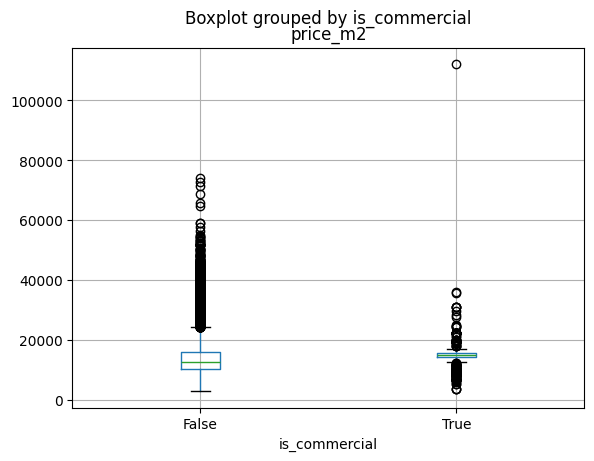

In [33]:
df.boxplot(column="price_m2", by="is_commercial")

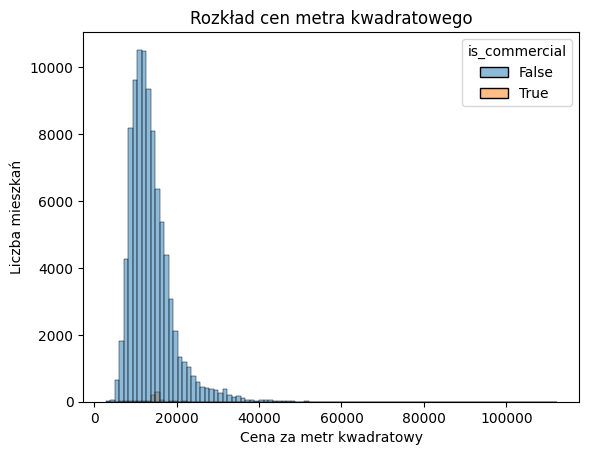

In [39]:
sns.histplot(data=df,
             x="price_m2",
             bins = 100,
             hue="is_commercial"
             )
plt.title("Rozkład cen metra kwadratowego")
plt.xlabel("Cena za metr kwadratowy")
plt.ylabel("Liczba mieszkań")
plt.show()

In [40]:

100 * df[df["price_m2"] > 30_000].shape[0] / df.shape[0]

1.8137354799266354

### Odcinamy mieszkania poniżj 5k/m2 i powyżej 30k/m2

In [43]:
df = df.query("price_m2>=5000 & price_m2 <= 30000")

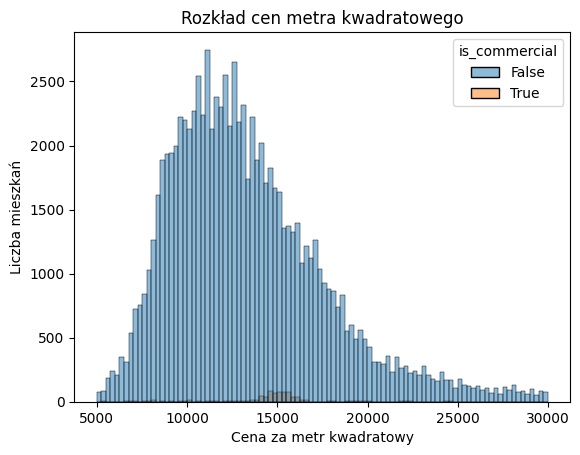

In [44]:
sns.histplot(data=df,
             x="price_m2",
             bins = 100,
             hue="is_commercial"
             )
plt.title("Rozkład cen metra kwadratowego")
plt.xlabel("Cena za metr kwadratowy")
plt.ylabel("Liczba mieszkań")
plt.show()

### Dodamy odzielnie samodzielne domy

In [45]:
df["is_detached"] = df["floor"]==-1

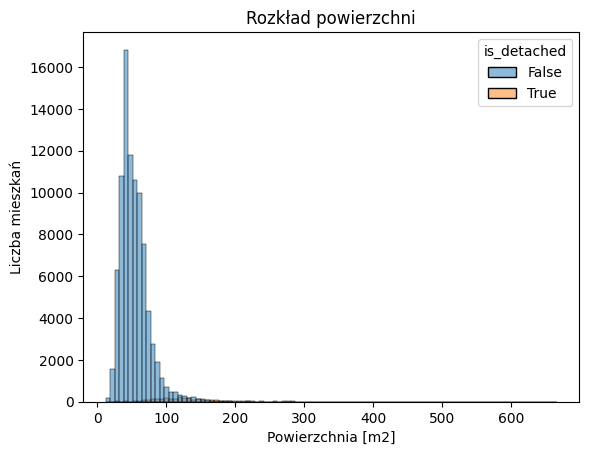

In [47]:
sns.histplot(data=df,
             x="area",
             bins = 100,
             hue="is_detached"
             )
plt.title("Rozkład powierzchni")
plt.xlabel("Powierzchnia [m2]")
plt.ylabel("Liczba mieszkań")
plt.show()

In [48]:
100* df.query("area>200").shape[0] / df.shape[0]

0.38263911665026784

In [49]:
df = df.query("area <= 200")

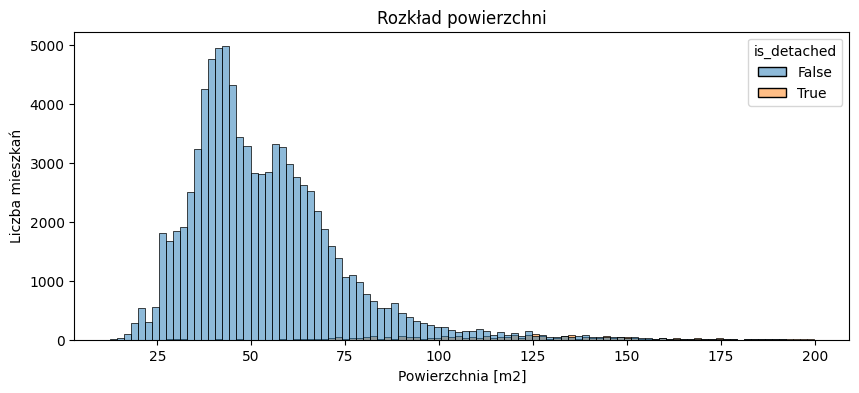

In [51]:
plt.figure(figsize=(10,4))
sns.histplot(data=df,
             x="area",
             bins = 100,
             hue="is_detached"
             )
plt.title("Rozkład powierzchni")
plt.xlabel("Powierzchnia [m2]")
plt.ylabel("Liczba mieszkań")
plt.show()

### wykres rozkładu punktów

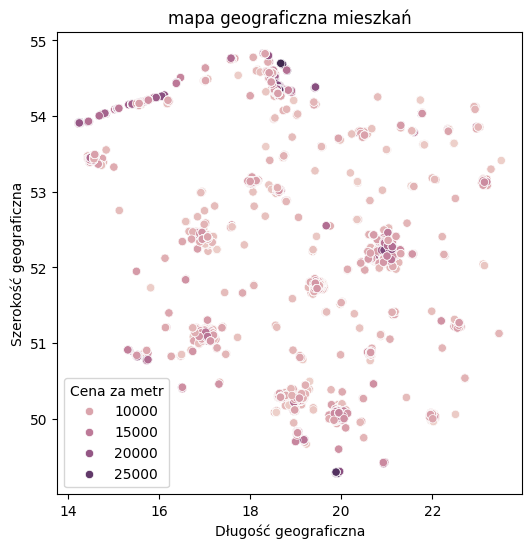

In [59]:
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=df,
    x="lat",
    y="lng",
    hue="price_m2",
    #palette="coolwarm"
)
plt.title("mapa geograficzna mieszkań")
plt.xlabel("Długość geograficzna")
plt.ylabel("Szerokość geograficzna")
plt.legend(title="Cena za metr")
plt.show()

 Zatem wniosek: mamy źle nazwane kolumny związane ze współrzędnymi geograficznymi.

In [60]:
df = df.rename(columns={"lng": "lat", "lat": "lng"})


i całość zapisujemy, na przykład jako plik typu *.parquet, który ma kilka przydatnych cech, dla nas najważniejszą jest zachowanie typów danych (liczby są liczbami, napisy napisami).
Możesz oczywiście użyć pandasowego .to_excel() i zapisać dane do Excela, jak sobie chcesz. Tylko nie zdziw się później, że niektóre kolumny będą datą.

In [61]:

df.to_parquet("ceny_mieszkan_v1.parquet", index=False)